In [4]:
import numpy as np
import discretize
import matplotlib.pyplot as plt

import sys, os
sys.path.append(os.path.abspath("../../../../"))

from Forward.MT3D import compute_mt_impedance_tipper
from Forward.utils import apparent_resistivity
from Forward.utils import phase_deg

In [13]:
# 1) Modelo (Δσ)
# El NPY trae contraste de conductividad Δσ en S/m 

frequency_list = np.logspace(-4, 2, 7)

# Ubicación del receptor para el modelado
receivers = np.array([
    [0.0, 0.0, 0.0],
])

# Carga de la malla usada para el modelo 1D de conductividad
mesh = discretize.utils.load_mesh("../../../../models/Toy3/mesh_Toy3_MT.json")

# Carga del modelo 1D de conductividad
sigma = np.load("../../../../models/Toy3/model_Toy3_MT.npy", allow_pickle=True)

print("mesh =", mesh)
print("mesh.nC=", mesh.nC)
print("mesh.nEx=", mesh.nEx)
print("mesh.nEy=", mesh.nEy)
print("mesh.nEz=", mesh.nEz)
print("frequency_list =", frequency_list)
print("receivers =", receivers)

mesh = 
  TensorMesh: 4,312 cells

                      MESH EXTENT             CELL WIDTH      FACTOR
  dir    nC        min           max         min       max      max
  ---   ---  ---------------------------  ------------------  ------
   x     14     -3,439.01      3,439.01    250.00    928.23    1.30
   y     14     -3,439.01      3,439.01    250.00    928.23    1.30
   z     22     -3,087.43      3,387.43    150.00    724.02    1.30


mesh.nC= 4312
mesh.nEx= 4830
mesh.nEy= 4830
mesh.nEz= 4950
frequency_list = [1.e-04 1.e-03 1.e-02 1.e-01 1.e+00 1.e+01 1.e+02]
receivers = [[0. 0. 0.]]


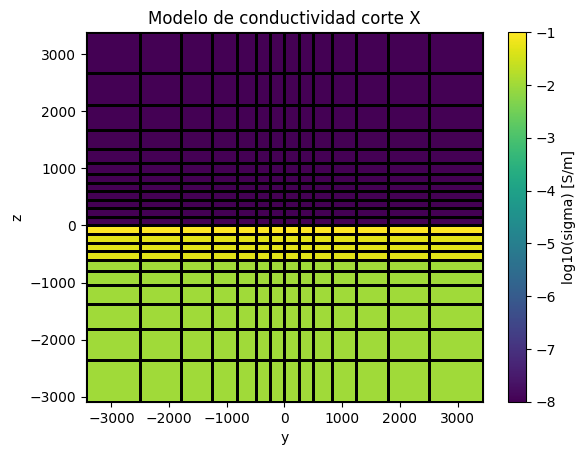

In [3]:
# 2) Plot del modelo de conductividad
collect_obj = mesh.plot_slice(np.log10(sigma), grid=True, normal="X")[0]
plt.colorbar(collect_obj, label="log10(sigma) [S/m]")
plt.title("Modelo de conductividad corte X")
plt.show()

In [4]:
# 3) Forward
Z, T = compute_mt_impedance_tipper(mesh, sigma, receivers, frequency_list)

# Se guardan el tensor de impedancias y el tipper
np.save("impedance_Toy3_MT.npy", Z)
np.save("tipper_Toy3_MT.npy", T)

## Se imprimen los resultados obtenidos
print("Computed shapes -> Z:", Z.shape, "T:", T.shape)

for i, r in enumerate(receivers):
    for j, f in enumerate(frequency_list):
        print(
            f"Rec {i} {r}, f={f} Hz -> "
            f"Zxy={Z[i,j,0,1]:.4e}, Zyx={Z[i,j,1,0]:.4e}, "
            f"Tzx={T[i,j,0]:.4e}, Tzy={T[i,j,1]:.4e}"
        )

Resolviendo para la frecuencia 0 de 7
calculando la impedancia en el receptor   0/1 at [0. 0. 0.], por favor espere :)
Resolviendo para la frecuencia 1 de 7
calculando la impedancia en el receptor   0/1 at [0. 0. 0.], por favor espere :)
Resolviendo para la frecuencia 2 de 7
calculando la impedancia en el receptor   0/1 at [0. 0. 0.], por favor espere :)
Resolviendo para la frecuencia 3 de 7
calculando la impedancia en el receptor   0/1 at [0. 0. 0.], por favor espere :)
Resolviendo para la frecuencia 4 de 7
calculando la impedancia en el receptor   0/1 at [0. 0. 0.], por favor espere :)
Resolviendo para la frecuencia 5 de 7
calculando la impedancia en el receptor   0/1 at [0. 0. 0.], por favor espere :)
Resolviendo para la frecuencia 6 de 7
calculando la impedancia en el receptor   0/1 at [0. 0. 0.], por favor espere :)
Computed shapes -> Z: (1, 7, 2, 2) T: (1, 7, 2)
Rec 0 [0. 0. 0.], f=0.0001 Hz -> Zxy=-9.0931e-05-9.1083e-05j, Zyx=9.0931e-05+9.1083e-05j, Tzx=9.5197e-14-9.5839e-14j, T

In [5]:
# Se calculan los valores de resistividad y fase aparente para
# Tensor de impedancias
Zxx = Z[:, :, 0, 0]
Zxy = Z[:, :, 0, 1]
Zyx = Z[:, :, 1, 0]
Zyy = Z[:, :, 1, 1]

rhoxx = apparent_resistivity(Zxx, frequency_list)
rhoxy = apparent_resistivity(Zxy, frequency_list)
rhoyx = apparent_resistivity(Zyx, frequency_list)
rhoyy = apparent_resistivity(Zyy, frequency_list)

phixx = phase_deg(Zxx)
phixy = phase_deg(Zxy)
phiyx = phase_deg(Zyx)
phiyy = phase_deg(Zyy)

# Tipper
Tzx=T[:,:,0]
Tzy=T[:,:,1]

Tmzx = np.abs(Tzx)
Tmzy = np.abs(Tzy)

Tpzx = phase_deg(Tzx)
Tpzy = phase_deg(Tzy)

## Se imprimen los valores numéricos
print("Zxy:", Z[:, :, 0, 1])
print("Zyx:", Z[:, :, 1, 0])
print("Zxx:", Z[:, :, 0, 0])
print("Zyy:", Z[:, :, 1, 1])
print("Tzx:", T[:, :, 0])
print("Tzy:", T[:, :, 1])
print("|Tzx|:", Tmzx[:])
print("|Tzy|:", Tmzy[:])
print("Tzx°:", Tpzx[:])
print("Tzy°:", Tpzy[:])

Zxy: [[-9.09309052e-05-9.10831408e-05j -2.87570081e-04-2.89060084e-04j
  -9.10053375e-04-9.23926825e-04j -2.89939276e-03-3.00531346e-03j
  -9.80665921e-03-9.80454507e-03j -3.05774836e-02-2.00407365e-02j
  -8.60066108e-02-6.26612838e-02j]]
Zyx: [[9.09309052e-05+9.10831409e-05j 2.87570081e-04+2.89060084e-04j
  9.10053375e-04+9.23926825e-04j 2.89939276e-03+3.00531346e-03j
  9.80665921e-03+9.80454507e-03j 3.05774836e-02+2.00407365e-02j
  8.60066108e-02+6.26612838e-02j]]
Zxx: [[-1.55068836e+07-1.80215271e+09j -1.16173701e+08-3.17929704e+10j
  -3.33704580e+08+4.59824774e+10j -1.60126528e+10+4.37329080e+11j
   1.15768355e+12-9.17021990e+12j  1.23166089e+12+4.12089894e+12j
  -9.91635732e+13-5.82618555e+13j]]
Zyy: [[-8.45258231e+05-6.75295705e+08j -3.41129660e+06+1.51220689e+09j
   1.31671881e+08-1.13547618e+10j  2.62204221e+11-1.01614901e+12j
  -1.57255962e+12+3.30999830e+12j -9.06025874e+11-2.13065760e+13j
   2.28639413e+14+2.24798418e+14j]]
Tzx: [[ 9.51968905e-14-9.58388316e-14j  3.48644595e

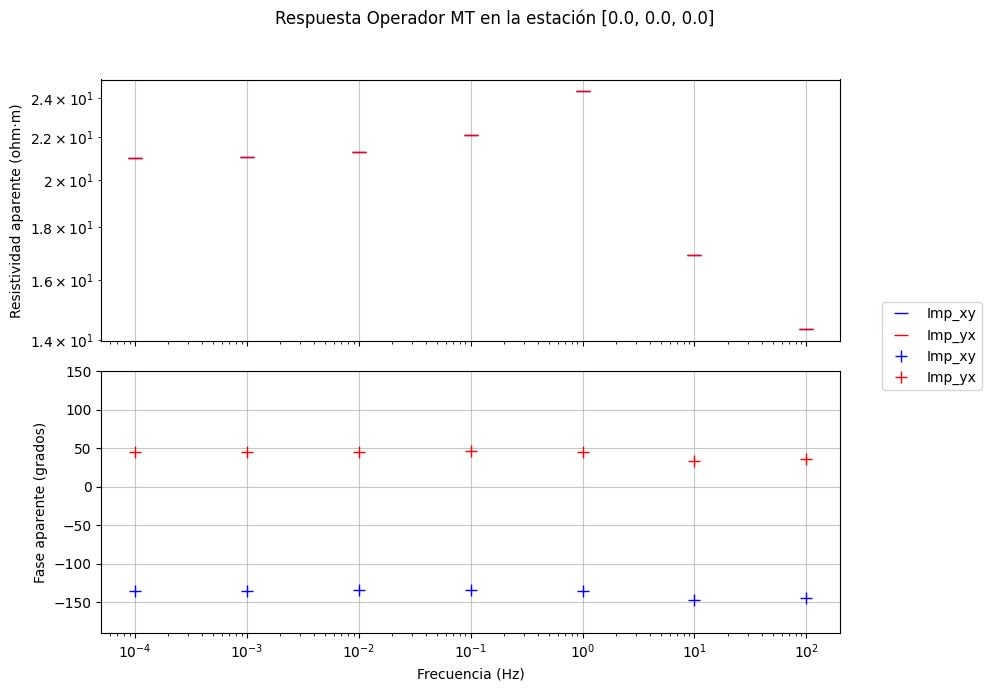

In [6]:
# 4) Plot de resistividad y fase aparente

frec = frequency_list

# Receptor a graficar
irec = 0

# Colores por componente
c_xx = "green"
c_xy = "blue"
c_yx = "red"
c_yy = "gold"

fig, (ax_rho, ax_phi) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

# Resistividad
ax_rho.plot(frec, rhoxy[irec, :], marker="_", linestyle="none", color=c_xy, markersize=10, label="Imp_xy")
ax_rho.plot(frec, rhoyx[irec, :], marker="_", linestyle="none", color=c_yx, markersize=10, label="Imp_yx")

ax_rho.set_xscale("log")
ax_rho.set_yscale("log")
ax_rho.set_ylabel("Resistividad aparente (ohm·m)")
ax_rho.grid(True, which="major", alpha=0.7)

# Fase
ax_phi.plot(frec, phixy[irec, :], marker="+", linestyle="none", color=c_xy, markersize=8, label="Imp_xy")
ax_phi.plot(frec, phiyx[irec, :], marker="+", linestyle="none", color=c_yx, markersize=8, label="Imp_yx")

ax_phi.set_xscale("log")
ax_phi.set_xlabel("Frecuencia (Hz)")
ax_phi.set_ylabel("Fase aparente (grados)")
ax_phi.grid(True, which="major", alpha=0.7)
ax_phi.set_ylim(-190, 150)

handles_rho, labels_rho = ax_rho.get_legend_handles_labels()
handles_phi, labels_phi = ax_phi.get_legend_handles_labels()

fig.legend(
    handles_rho + handles_phi,
    labels_rho + labels_phi,
    loc="center left",
    bbox_to_anchor=(0.88, 0.5)
)

fig.suptitle(f"Respuesta Operador MT en la estación {receivers[irec].tolist()}")

plt.tight_layout(rect=[0, 0, 0.86, 0.95])
plt.show()

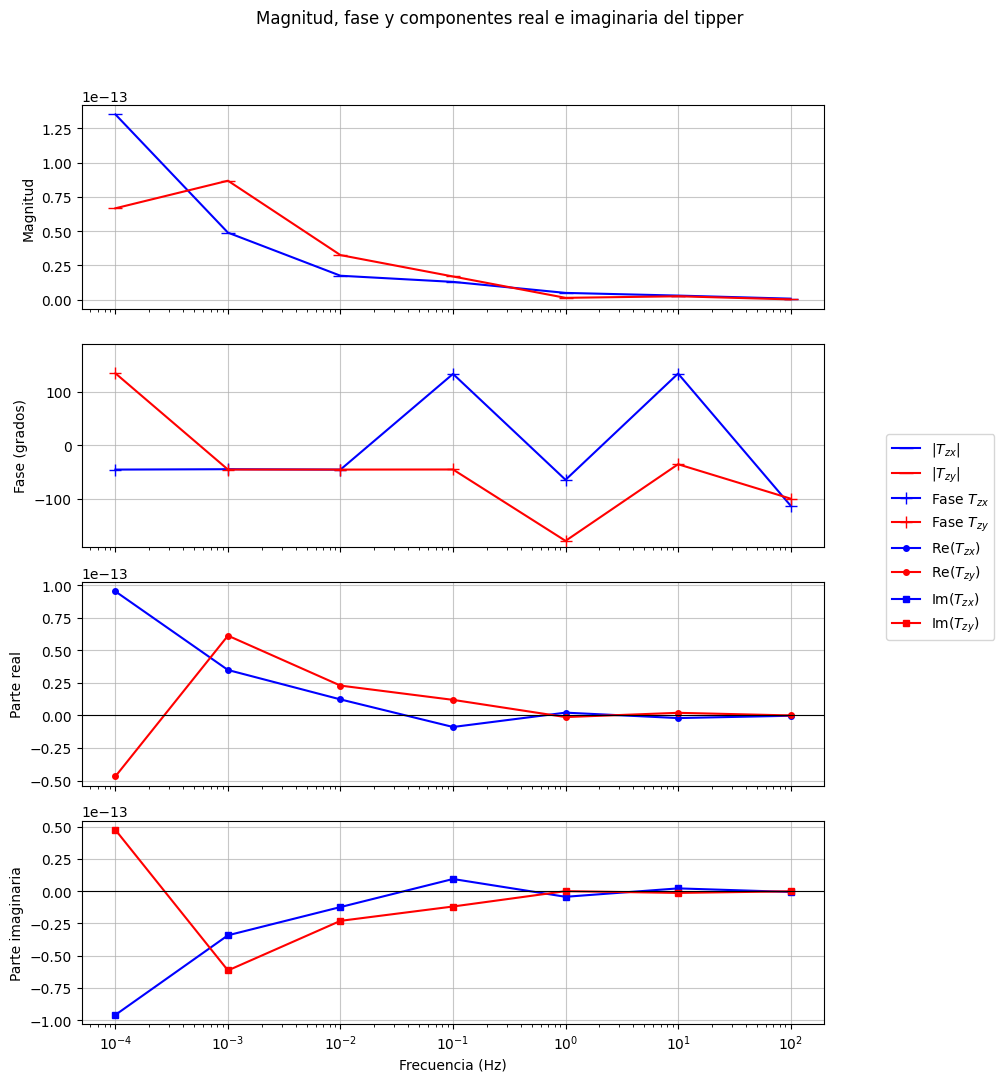

In [7]:
# Magnitud, fase, parte real e imaginaria del tipper
Tmzx = np.abs(Tzx)
Tmzy = np.abs(Tzy)

Tpzx = phase_deg(Tzx)
Tpzy = phase_deg(Tzy)

Tzx_real = np.real(Tzx)
Tzx_imag = np.imag(Tzx)

Tzy_real = np.real(Tzy)
Tzy_imag = np.imag(Tzy)

frec = frequency_list
irec = 0

# Colores por componente
c_tzx = "blue"
c_tzy = "red"

fig, (ax_mag, ax_phi, ax_real, ax_imag) = plt.subplots(
    4, 1,
    figsize=(10, 11),
    sharex=True
)

# Magnitud del tipper
ax_mag.plot(
    frec, Tmzx[irec, :],
    marker="_", linestyle="-",
    color=c_tzx, markersize=10,
    label=r"$|T_{zx}|$"
)

ax_mag.plot(
    frec, Tmzy[irec, :],
    marker="_", linestyle="-",
    color=c_tzy, markersize=10,
    label=r"$|T_{zy}|$"
)

ax_mag.set_xscale("log")
ax_mag.set_ylabel("Magnitud")
ax_mag.grid(True, which="major", alpha=0.7)

# Fase del tipper
ax_phi.plot(
    frec, Tpzx[irec, :],
    marker="+", linestyle="-",
    color=c_tzx, markersize=8,
    label=r"Fase $T_{zx}$"
)

ax_phi.plot(
    frec, Tpzy[irec, :],
    marker="+", linestyle="-",
    color=c_tzy, markersize=8,
    label=r"Fase $T_{zy}$"
)

ax_phi.set_xscale("log")
ax_phi.set_ylabel("Fase (grados)")
ax_phi.grid(True, which="major", alpha=0.7)
ax_phi.set_ylim(-190, 190)

# Parte real
ax_real.plot(
    frec, Tzx_real[irec, :],
    marker="o", linestyle="-",
    color=c_tzx, markersize=4,
    label=r"Re($T_{zx}$)"
)

ax_real.plot(
    frec, Tzy_real[irec, :],
    marker="o", linestyle="-",
    color=c_tzy, markersize=4,
    label=r"Re($T_{zy}$)"
)

ax_real.set_xscale("log")
ax_real.set_ylabel("Parte real")
ax_real.grid(True, which="major", alpha=0.7)
ax_real.axhline(0, color="black", linewidth=0.8)

# Parte imaginaria
ax_imag.plot(
    frec, Tzx_imag[irec, :],
    marker="s", linestyle="-",
    color=c_tzx, markersize=4,
    label=r"Im($T_{zx}$)"
)

ax_imag.plot(
    frec, Tzy_imag[irec, :],
    marker="s", linestyle="-",
    color=c_tzy, markersize=4,
    label=r"Im($T_{zy}$)"
)

ax_imag.set_xscale("log")
ax_imag.set_xlabel("Frecuencia (Hz)")
ax_imag.set_ylabel("Parte imaginaria")
ax_imag.grid(True, which="major", alpha=0.7)
ax_imag.axhline(0, color="black", linewidth=0.8)


handles, labels = [], []

for ax in [ax_mag, ax_phi, ax_real, ax_imag]:
    h, l = ax.get_legend_handles_labels()
    handles.extend(h)
    labels.extend(l)

fig.legend(
    handles,
    labels,
    loc="center left",
    bbox_to_anchor=(0.88, 0.5)
)

fig.suptitle("Magnitud, fase y componentes real e imaginaria del tipper")

plt.tight_layout(rect=[0, 0, 0.84, 0.95])
plt.show()